# DCT Laboratory — Volume I, Chapter 8
## Stochastic Enterprise Dynamics
**Seed `26108`** · Companion to the chapter and AXIOM Module **AXIOM-08**

The fiction is dropped: the environment channel is random, trajectories become
**fans**, and the state at $t$ is a **distribution**. Three instruments here: the
enterprise diffusion (GBM) with its analytic moments, the **flaw of averages**
made visible (mean path ≠ median path; $\mathbb{E}[f(X)] \ne f(\mathbb{E}[X])$),
and jump-diffusion — restructuring's stochastic home. The analytic core is
mirrored in `DCT_V1_Ch08_Lab.xlsx`; Monte Carlo fans live here.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi']=110

import numpy as np
from math import log, sqrt, exp, erf
SEED = 26108
X0, MU, SIG, T = 100.0, 0.08, 0.25, 5.0
BARRIER = 80.0
LAM_J, MJ = 0.4, 0.9          # jump intensity /yr, mean jump multiplier

def Phi(z): return 0.5*(1+erf(z/sqrt(2)))

def mean_T():   return X0*exp(MU*T)
def median_T(): return X0*exp((MU-SIG**2/2)*T)
def p_below_barrier():
    z = (log(BARRIER/X0)-(MU-SIG**2/2)*T)/(SIG*sqrt(T))
    return Phi(z)
def mean_T_jumps():   # compound Poisson multiplicative jumps
    return X0*exp((MU+LAM_J*(MJ-1))*T)

def mc_paths(n_paths=2000, steps=60):
    rng = np.random.default_rng(SEED)
    dt = T/steps
    z = rng.standard_normal((n_paths, steps))
    logx = np.cumsum((MU-SIG**2/2)*dt + SIG*sqrt(dt)*z, axis=1)
    return X0*np.exp(np.hstack([np.zeros((n_paths,1)), logx]))

def mc_jump_paths(n_paths=2000, steps=60):
    rng = np.random.default_rng(SEED+1)
    dt = T/steps
    z = rng.standard_normal((n_paths, steps))
    nj = rng.poisson(LAM_J*dt, (n_paths, steps))
    logx = np.cumsum((MU-SIG**2/2)*dt + SIG*sqrt(dt)*z + nj*log(MJ), axis=1)
    return X0*np.exp(np.hstack([np.zeros((n_paths,1)), logx]))

def reference_values():
    return {
        "mean_t5":        round(mean_T(), 4),
        "median_t5":      round(median_T(), 4),
        "mean_median_gap":round(mean_T()-median_T(), 4),
        "p_breach_t5":    round(p_below_barrier(), 4),
        "mean_t5_jumps":  round(mean_T_jumps(), 4),
        "jump_drag":      round(mean_T()-mean_T_jumps(), 4),
        "sigma_sqrtT":    round(SIG*sqrt(T), 4),
    }
if __name__ == "__main__":
    [print(f"{k:18s} {v}") for k,v in reference_values().items()]

mean_t5            149.1825
median_t5          127.6025
mean_median_gap    21.5799
p_breach_t5        0.2018
mean_t5_jumps      122.1403
jump_drag          27.0422
sigma_sqrtT        0.559


## Panel 1 — The fan, and two "forecasts" inside it
2,000 GBM paths, seed `26108`. The **mean path** (what the Expected Enterprise
Evolution Theorem tracks) and the **median path** diverge — at $t=5$ they are
21.6 apart on a base of 100. The mean is dragged up by a thin right tail; the
median is what the typical path does. Deterministic dynamics are the degenerate
case (Prop.): switch $\sigma$ to 0 and the fan collapses to Chapter 7.

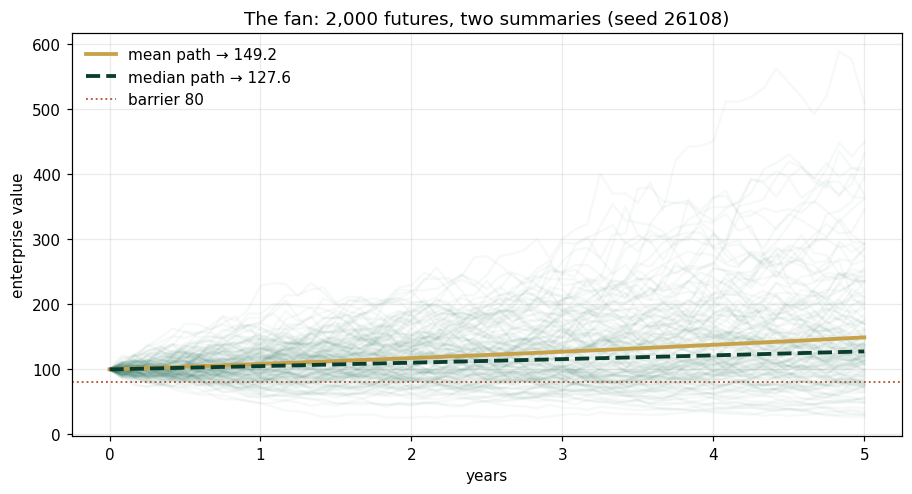

analytic mean 149.1825   MC mean 150.3499
analytic median 127.6025   MC median 129.9764


In [2]:
paths = mc_paths()
t = np.linspace(0, T, paths.shape[1])
fig, ax = plt.subplots(figsize=(8.4,4.6))
ax.plot(t, paths[:150].T, color="#1B6B52", alpha=.04)
ax.plot(t, X0*np.exp(MU*t), c="#C8A24B", lw=2.5, label=f"mean path → {mean_T():.1f}")
ax.plot(t, X0*np.exp((MU-SIG**2/2)*t), c="#0B3D2E", lw=2.5, ls="--", label=f"median path → {median_T():.1f}")
ax.axhline(BARRIER, c="#B0532F", lw=1.2, ls=":", label=f"barrier {BARRIER:.0f}")
ax.set(xlabel="years", ylabel="enterprise value", title="The fan: 2,000 futures, two summaries (seed 26108)")
ax.legend(frameon=False); ax.grid(alpha=.25); plt.tight_layout(); plt.show()
print(f"analytic mean {mean_T():.4f}   MC mean {paths[:,-1].mean():.4f}")
print(f"analytic median {median_T():.4f}   MC median {np.median(paths[:,-1]):.4f}")

## Panel 2 — The flaw of averages, exactly
Two demonstrations. **(a)** The mean–median gap above: "the average outcome"
and "the typical outcome" are different numbers. **(b)** $\mathbb{E}[f(X)]
\ne f(\mathbb{E}[X])$ for the breach indicator $f(x) = \mathbf{1}[x < 80]$:
evaluated **at the mean**, the breach "cannot happen" ($f(149.2) = 0$); in
**expectation**, it happens with probability 0.2018 — one path in five.
Planning on the mean path deletes a 20% event.

In [3]:
p_analytic = p_below_barrier()
p_mc = float((paths[:,-1] < BARRIER).mean())
print(f"f(E[X_5]) = 1[{mean_T():.1f} < 80]        = 0        (the mean-path plan)")
print(f"E[f(X_5)] = P(X_5 < 80)  analytic = {p_analytic:.4f}")
print(f"                          MC       = {p_mc:.4f}   (2,000 paths)")

f(E[X_5]) = 1[149.2 < 80]        = 0        (the mean-path plan)
E[f(X_5)] = P(X_5 < 80)  analytic = 0.2018
                          MC       = 0.2165   (2,000 paths)


## Panel 3 — Jumps: restructuring's stochastic home
A compound-Poisson jump component ($\lambda = 0.4$/yr, mean multiplier 0.9)
riding on the diffusion — the Jump-Diffusion Theorem's world. The jump drag on
the mean is analytic: $\mathbb{E}[X_T] = x_0 e^{(\mu + \lambda(m-1))T}$, a
27-point haircut at $t=5$.

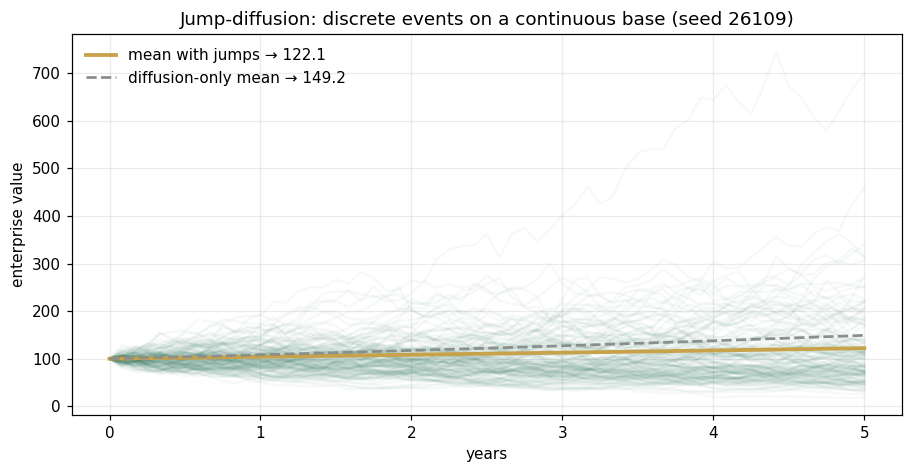

jump drag at t=5 (analytic): 27.0422
MC mean with jumps: 120.1459


In [4]:
jp = mc_jump_paths()
fig, ax = plt.subplots(figsize=(8.4,4.4))
ax.plot(t, jp[:150].T, color="#1B6B52", alpha=.04)
ax.plot(t, X0*np.exp((MU+LAM_J*(MJ-1))*t), c="#C8A24B", lw=2.5, label=f"mean with jumps → {mean_T_jumps():.1f}")
ax.plot(t, X0*np.exp(MU*t), c="#8A8F8B", lw=1.8, ls="--", label=f"diffusion-only mean → {mean_T():.1f}")
ax.set(xlabel="years", ylabel="enterprise value", title="Jump-diffusion: discrete events on a continuous base (seed 26109)")
ax.legend(frameon=False); ax.grid(alpha=.25); plt.tight_layout(); plt.show()
print(f"jump drag at t=5 (analytic): {mean_T()-mean_T_jumps():.4f}")
print(f"MC mean with jumps: {jp[:,-1].mean():.4f}")

## Validation — agrees with `DCT_V1_Ch08_Lab.xlsx` (analytic core)

In [5]:
ref = reference_values()
expected = {"mean_t5":149.1825,"median_t5":127.6025,"mean_median_gap":21.5799,
 "p_breach_t5":0.2018,"mean_t5_jumps":122.1403,"jump_drag":27.0422,"sigma_sqrtT":0.559}
for k,v in expected.items():
    assert abs(ref[k]-v)<5e-4, f"MISMATCH {k}"
    print(f"PASS  {k:18s} {ref[k]}")
print("\nAll checkpoints agree — seed 26108.")

PASS  mean_t5            149.1825
PASS  median_t5          127.6025
PASS  mean_median_gap    21.5799
PASS  p_breach_t5        0.2018
PASS  mean_t5_jumps      122.1403
PASS  jump_drag          27.0422
PASS  sigma_sqrtT        0.559

All checkpoints agree — seed 26108.


**Next**: Exercises 8.9–8.12 (Part C) vary σ, λ, and the barrier; AXIOM-08's fan theater animates Panel 1 with a σ-slider whose zero position is Chapter 7. Solutions: IM Ch. 8.